In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.cm as cm

from sys import path # Needed if running code from repo
path.append("../../../")

import larp
import larp.io as lpio

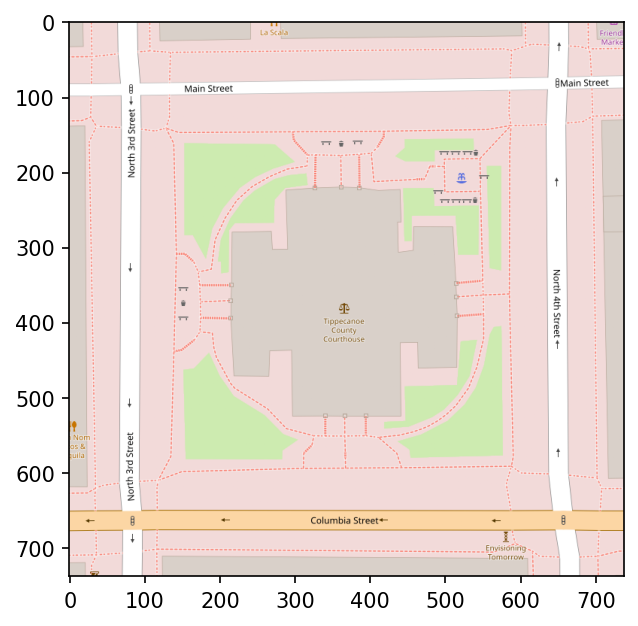

In [2]:
img = mpimg.imread('map.png')

plt.figure(dpi=150)
plt.imshow(img)
plt.axis(True)
plt.show()

In [3]:
field = lpio.loadRGeoJSONFile('city_court.rgj')

penalty_scaler = lambda p: 1/(1.1*(1.0 - p + 1e-10))
display, extent = field.to_image(400)

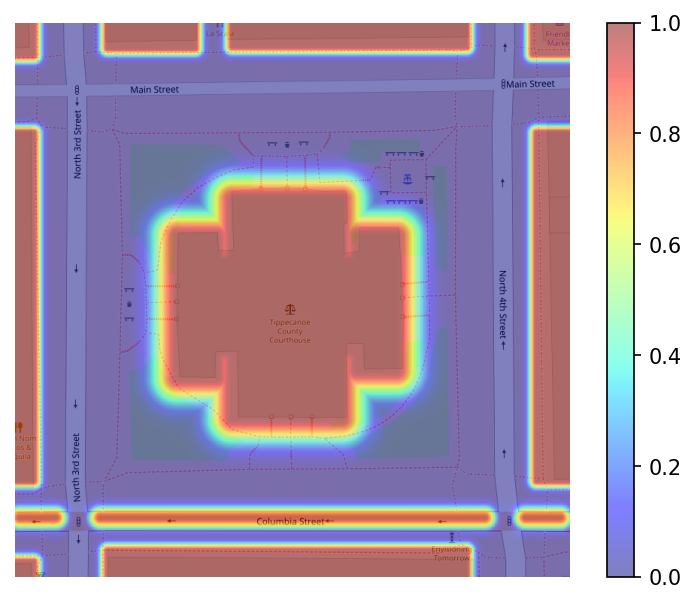

In [4]:

plt.figure(dpi=150)
plt.imshow(img, extent=extent)
plt.imshow(display, cmap='jet', alpha=0.5, extent=extent)
plt.axis(False)
plt.colorbar()
plt.clim(0.0,1.0)
plt.show()

In [5]:
edges = [0.1, 0.2, 0.4, 0.6, 0.8]
quadtree = larp.quad.QuadTree(field, minimum_length_limit=5, edge_bounds=edges)

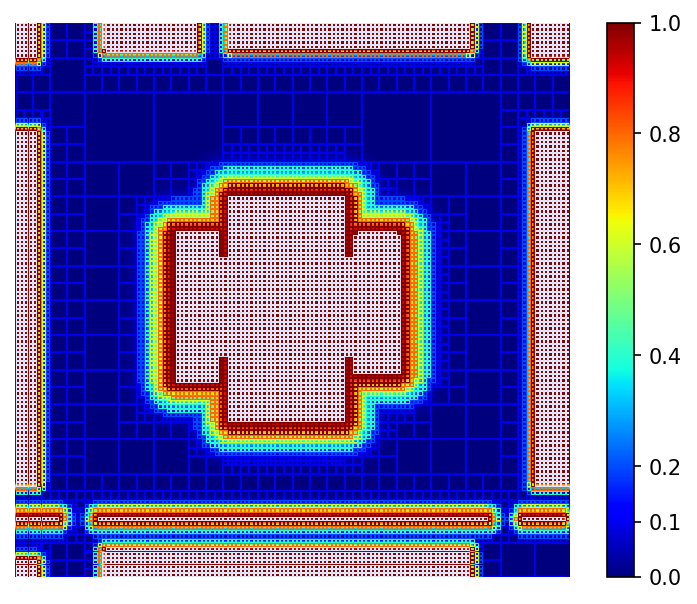

In [6]:
boundaries_lines = quadtree.to_boundary_lines_collection(margin=0.7)
boundaries_lines_zones = quadtree.get_quad_zones()

plt.figure(dpi=150)
plt.imshow(display, cmap='jet', extent=extent)
plt.axis(False)
plt.colorbar().set_ticks([0.0] + edges + [1.0])
for i in range(0, len(boundaries_lines), 2):
    zone = boundaries_lines_zones[i//2]
    c = cm.jet(quadtree.ZONEToMaxRANGE[zone]) if zone > 0 else "#e4ebff"
    plt.plot(*boundaries_lines[i:i+2], c=c, alpha=1, linewidth=0.5)
plt.show()

In [7]:
start = (50, 30) # (x, y)
end = (660, 660)

planner = larp.pp.QuadPlanner(quadtree=quadtree)
planner.select_alg("a*")
path = planner.find_path(start, end, scaler=penalty_scaler)

print(f"Route found: {path is not None}")

Route found: True


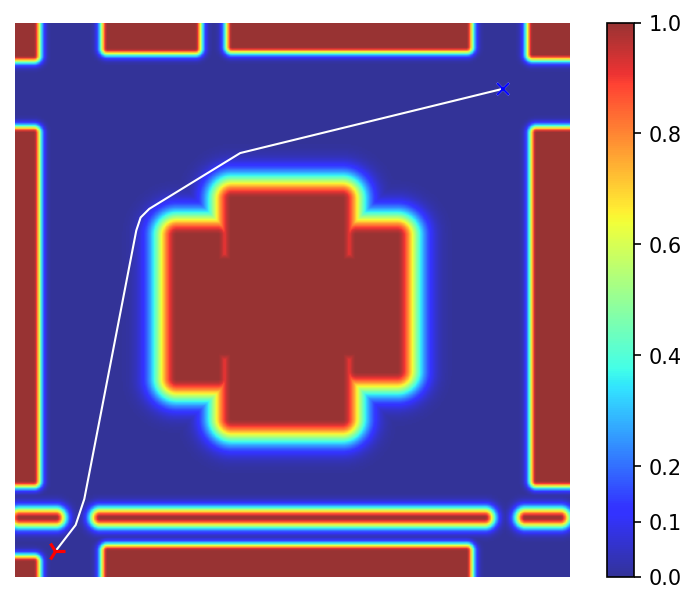

In [8]:
plt.figure(dpi=150)
plt.imshow(display, cmap='jet', extent=extent, alpha=0.8)
plt.colorbar().set_ticks([0.0] + edges + [1.0])
plt.plot(path[:, 0], path[:, 1], color="#fff", alpha=1.0, linewidth=1.0)
plt.plot(path[0, 0], path[0, 1], 'r4', markersize=10.0, markeredgewidth=1.5)
plt.plot(path[-1, 0], path[-1, 1], 'wx')
plt.plot(end[0], end[1], 'bx')
plt.axis(False)
plt.show()